## Presentado por: Eduardo Perez

# Punto 1/4

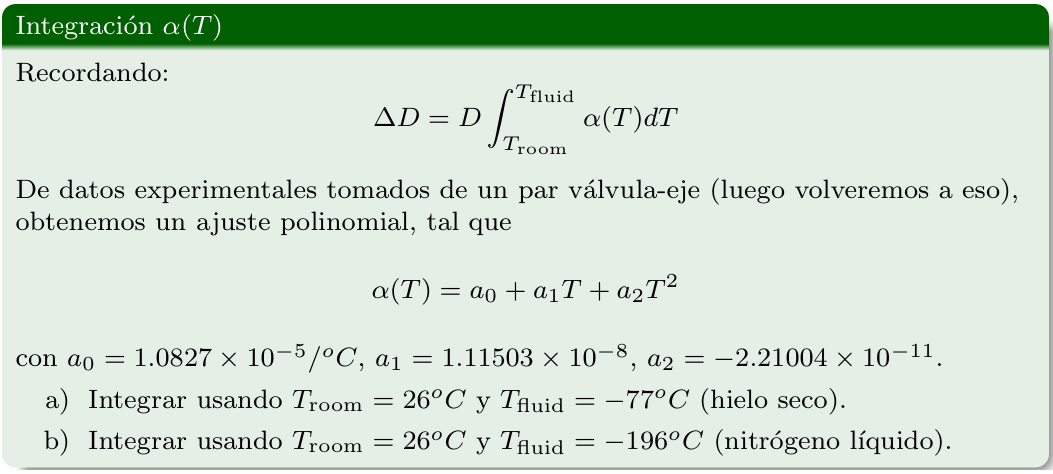

Calculando $\Delta D$ en función de $D$ integrando con la temperatura se tiene:
$$\Delta D = D\int_{T_{room}}^{T_{fluid}} \alpha(T)dT$$
$$= D\int_{T_{room}}^{T_{fluid}} (a_0 + a_1T + a_2 T^2)dT$$
$$= D(a_0T + \frac{a_1T^2}{2} + \frac{a_2 T^3}{3})|_{T_{room}}^{T_{fluid}}
$$

Reemplazando los parámetros por los valores dados por el ejercicio se tiene lo siguiente:

In [15]:
a0 = 1.0827e-5 
a1 = 1.11503e-8
a2 = -2.21004e-11

T_room_a = T_room_b = 26
T_fluid_a = -77
T_fluid_b = -196

D_a = (a0*T_fluid_a + (a1*T_fluid_a**2)/2 + (a2*T_fluid_a**3)/3) - (a0*T_room_a + (a1*T_fluid_a**2)/2 + (a2*T_fluid_a**3)/3)
D_b = (a0*T_fluid_b + (a1*T_fluid_b**2)/2 + (a2*T_fluid_b**3)/3) - (a0*T_room_b + (a1*T_fluid_b**2)/2 + (a2*T_fluid_b**3)/3)

print("result for a) ",round(D_a,5))
print("result for b) ",round(D_b,5))

result for a)  -0.00112
result for b)  -0.0024


Por el cálculo hecho anterimormente se tiene que los resultados son:

a) $\alpha = -1.12x10^{-3} D$

b) $\alpha = -2.4x10^{-3} D$

# Punto 2/4

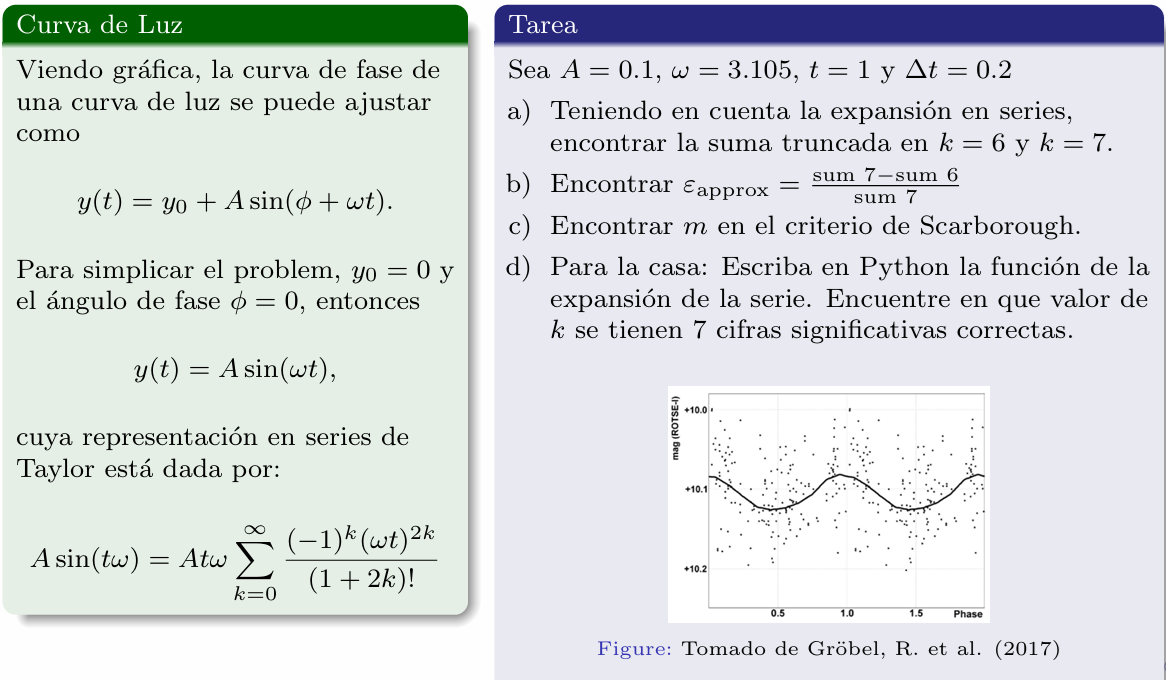

Para hacer este punto es necesario despejar $m$ en el criterio de Scarborough, poninedo una igualdad en vez de la desigualdad: $|\epsilon_{approx}| = \frac{1}{2} \times 10^{2-m}$. Esto se hace a continuación:

$\frac{1}{2} \times 10^{2-m} = |\epsilon_{approx}|$

$10^{2-m} = 2|\epsilon_{approx}|$

$2-m = \log(2|\epsilon_{approx}|)$

$m-2 = -\log(2|\epsilon_{approx}|)$

$m = 2 - \log(2|\epsilon_{approx}|)$

In [25]:
import math

def y(A,t,w,n):
  partial_y = 0
  for k in range(n):
    up = ((-1)**k) * ((w*t)**(2*k))
    low = math.factorial(1+2*k)
    partial_y += up/low
  return A*t*w*partial_y

AA = 0.1
W = 3.105
T = 1

#----------------------------------------- a ----------------------------------
print("a)")
y_6 = y(AA,T,W,n=6)
print("Suma truncada para k = 6 es y = ",y_6)

y_7 = y(AA,T,W,n=7)
print("Suma truncada para k = 7 es y = ",y_7)

#----------------------------------------- b ----------------------------------
print("b)")
e_approx = ((y_7-y_6)/y_7)*100
print("El error aproximado es: ",e_approx)

#----------------------------------------- c ----------------------------------
## Despejando la m en el criterio de Scarborough se tiene que m = 2-log_10(2*|e_aprox|)
m = 2-math.log10(2*abs(e_approx))
print("c)")
print("m = ",m," cuya parte entera es: ", int(m))

#----------------------------------------- d ----------------------------------
def k_function(A,t,w):
    k = 2
    y_i = y(A,t,w,k-1)
    y_ii = y(A,t,w,k)
    error = ((y_ii-y_i)/y_ii)*100
    m = int(2-math.log10(2*abs(e_approx)))
    figures = 7
    while m < figures:
        k += 1
        y_i = y_ii
        y_ii = y(A,t,w,k)
        error = (y_ii-y_i)/y_ii
        if error == 0:
            break
        m = int(2-math.log10(2*abs(e_approx)))
    return k

print("d)")
print("El valor de k (el número de sumas en la sucesión) para el cual se tienen 7 cifras significativas correctas es: ", k_function(AA, W, T))

a)
Suma truncada para k = 6 es y =  0.003620181303181452
Suma truncada para k = 7 es y =  0.0036602237439905616
b)
El error aproximado es:  1.0939888818232055
c)
m =  1.6599570960382108  cuya parte entera es:  1
d)
El valor de k (el número de sumas en la sucesión) para el cual se tienen 7 cifras significativas correctas es:  16


# Punto 3/4
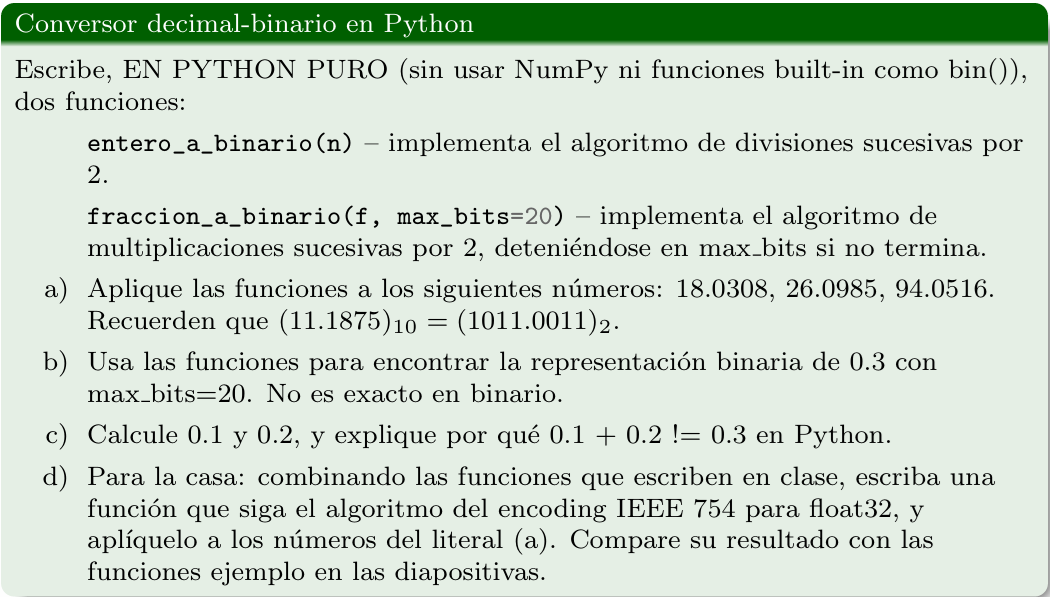